# Unsupervised Machine Learning – Complete Practical Guide

This notebook provides a **detailed teaching workflow for Unsupervised Machine Learning**.

Sections include:
- Problem understanding
- Data analysis
- Feature scaling
- Clustering (K-Means)
- Hierarchical clustering
- Dimensionality reduction (PCA)
- Cluster interpretation
- Student exercises

Dataset size: **10,000 customers**


## 1. Import Libraries

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA #principal component analysis 


## 2. Load Dataset

In [16]:

df = pd.read_csv("customer_segmentation_clear_clusters.csv")
df.head()


,age,annual_income,spending_score,online_purchase_frequency,store_visits_per_month
0,38.0,93974.0,75.0,9,3
1,38.0,88894.0,79.0,5,6
2,26.0,95182.0,74.0,9,6
3,41.0,102184.0,78.0,8,4
4,20.0,88127.0,65.0,10,2


## 3. Data Understanding

Features describe customer behavior:

- age
- annual_income
- spending_score
- online_purchase_frequency
- store_visits_per_month
- time_spent_on_app_minutes

Instructor Activity:
Explain how these variables relate to customer behavior.

Student Task:
Propose possible customer segments.


In [17]:
df.describe()

,age,annual_income,spending_score,online_purchase_frequency,store_visits_per_month
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,35.044600,62110.345500,49.982800,7.975000,5.034400
std,9.565049,27870.172654,23.822268,2.802278,2.236094
min,18.000000,14116.000000,-2.000000,0.000000,0.000000
25%,28.000000,34276.250000,28.000000,6.000000,3.000000
50%,35.000000,60099.500000,50.000000,8.000000,5.000000
75%,42.000000,90438.000000,72.000000,10.000000,6.000000
max,70.000000,120822.000000,111.000000,23.000000,15.000000


## 4. Exploratory Data Analysis

C:\Users\user\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


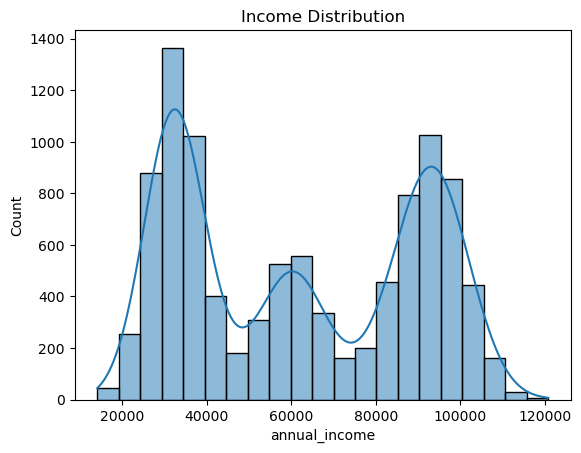

In [18]:

plt.figure()
sns.histplot(df['annual_income'], kde=True)
plt.title("Income Distribution")
plt.show()


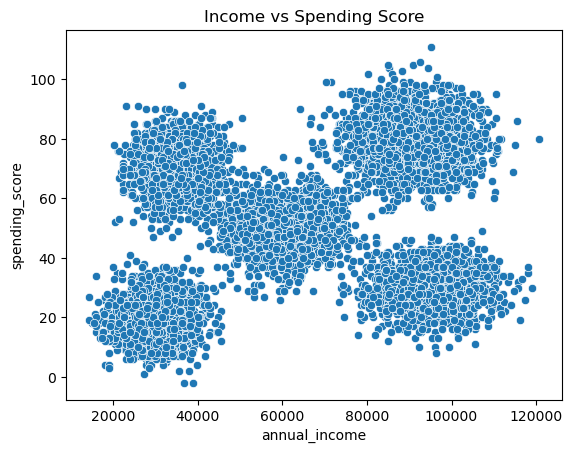

In [19]:

plt.figure()
sns.scatterplot(x='annual_income', y='spending_score', data=df)
plt.title("Income vs Spending Score")
plt.show()


Student Task:
Create additional plots to understand relationships between variables.


## 5. Feature Scaling

Clustering algorithms rely on distance.
Therefore features must be scaled.


In [20]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)


Student Task:
Explain why scaling is necessary for clustering algorithms.


## 6. K-Means Clustering

K-Means groups similar data points into clusters.


In [69]:

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df['cluster'] = clusters
df.head(20)


,age,annual_income,spending_score,online_purchase_frequency,store_visits_per_month,cluster,hier_cluster
0,38.0,93974.0,75.0,9,3,1,0
1,38.0,88894.0,79.0,5,6,1,0
2,26.0,95182.0,74.0,9,6,1,0
3,41.0,102184.0,78.0,8,4,1,0
4,20.0,88127.0,65.0,10,2,1,2
5,28.0,88127.0,82.0,3,2,1,0
6,18.0,102634.0,80.0,7,5,1,0
7,51.0,96139.0,73.0,7,6,1,0
8,33.0,86244.0,85.0,7,1,1,0
9,57.0,94340.0,88.0,14,2,1,0


In [70]:
df['cluster'].value_counts()

cluster
1    5756
2    2134
0    2110
Name: count, dtype: int64

In [71]:
print("Inertia:", kmeans.inertia_)

Inertia: 36867.5028686804


The inertia value of 36867.50 represents the total within-cluster variance. It measures how closely the data points are grouped around their respective cluster centers. Lower inertia indicates more compact clusters, but the value should be compared across different K values using the Elbow Method to determine the optimal number of clusters.

Student Task:
Experiment with different values of K.


## 7. Elbow Method

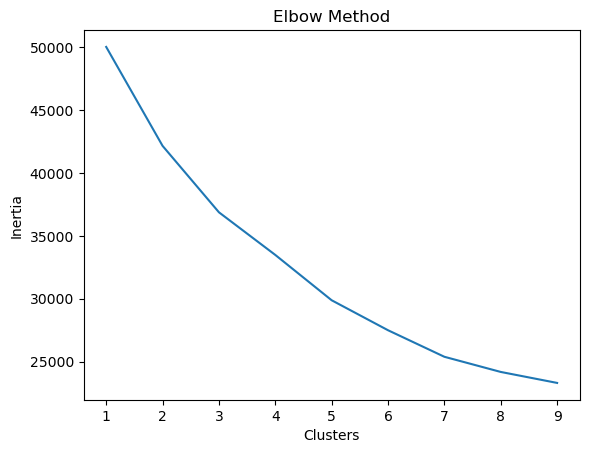

In [72]:

inertia = []

for k in range(1,10):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X_scaled)
    inertia.append(model.inertia_)

plt.plot(range(1,10), inertia)
plt.xlabel("Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()


Student Task:
Identify the optimal number of clusters.


## 8. Cluster Visualization

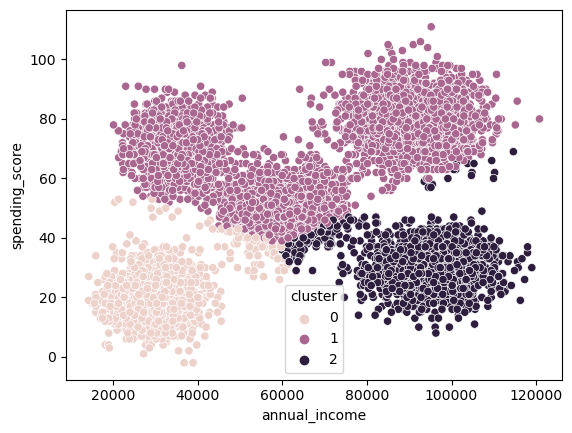

In [73]:

plt.figure()
sns.scatterplot(x='annual_income', y='spending_score', hue='cluster', data=df)
plt.show()


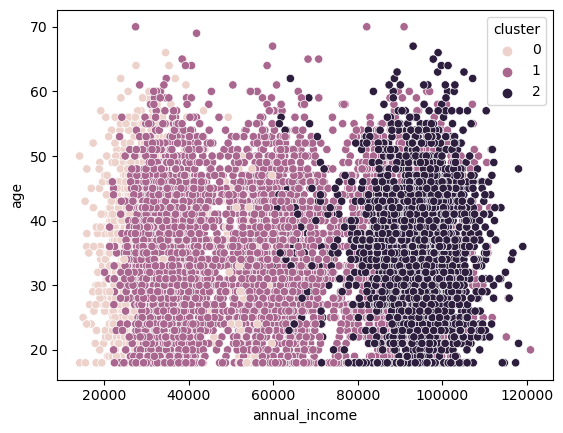

In [32]:

plt.figure()
sns.scatterplot(x='annual_income', y='age', hue='cluster', data=df)
plt.show()


# Student Task:
Describe characteristics of each cluster.


# Student Task:
1. Apply clustering with different K values.



## 9. Hierarchical Clustering

In [24]:

hier_model = AgglomerativeClustering(n_clusters=3)
hier_clusters = hier_model.fit_predict(X_scaled)

df['hier_cluster'] = hier_clusters


In [27]:
df['hier_cluster'].value_counts()

hier_cluster
0    5642
1    2364
2    1994
Name: count, dtype: int64

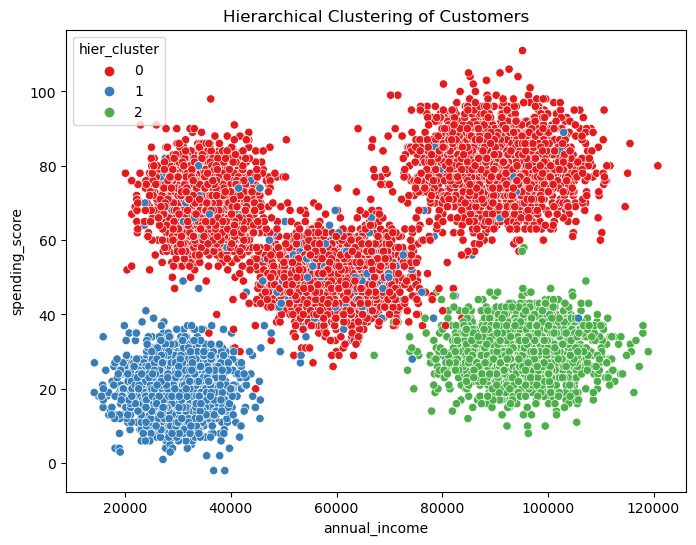

In [29]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='annual_income',
    y='spending_score',
    hue='hier_cluster',
    data=df,
    palette='Set1'
)

plt.title("Hierarchical Clustering of Customers")

plt.show()

# Student Task:
Compare hierarchical clustering with K-Means.


# Student Task:
Apply one more clustering/ unsupervised ML algorithm and compare the results of all three of them


# Feature selection using Unsupervised ML

## 10. Dimensionality Reduction with PCA

In [30]:
pca = PCA(n_components=2)

components = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(components, columns=['PC1','PC2'])

pca_df['cluster'] = clusters

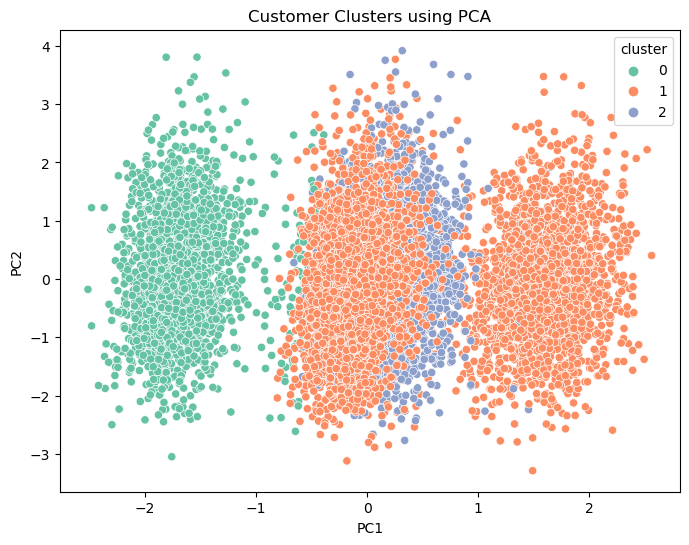

In [31]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='cluster',
    data=pca_df,
    palette='Set2'
)

plt.title("Customer Clusters using PCA")

plt.show()

Student Task:
Explain why PCA helps visualize clusters.


## 11. Cluster Interpretation

Instructor Activity:
Interpret clusters from a business perspective.


Example:

Cluster 0 → High income high spending customers

Cluster 1 → Low income moderate spending customers

Cluster 2 → Medium income low spending customers


# Kmeans POV

### Cluster 0 – Low Income, Low Spending

**Location**

- Left bottom area of the graph.

**Characteristics**

- Customers with **low annual income**
- Customers with **low spending behavior**

**Interpretation**

- These customers are **budget-conscious**
- They are likely **price-sensitive**

**Business Strategy**

- Provide **discount offers**
- Promote **budget-friendly products**

In [ ]:
# comtinue here 

## 12. Final Student Tasks

1. Apply clustering with different K values.
2. Compare K-Means and hierarchical clustering.
3. Try PCA with different components.
4. Write a business interpretation for clusters.
5. Suggest real-world applications.
